# **Proyek Analisis Data: Bike Sharing Dataset**
- **Nama:** Nurillah Tsany Wigati
- **Email:** nurillhts@gmail.com
- **ID Dicoding:** nurillht

## **Menentukan Pertanyaan Bisnis**

1. Bagaimana pola penyewaan sepeda pada tahun 2011 dan 2012?
2. Dapatkah data penyewaan sepeda menunjukkan pembagian bulan permusim?
3. Bagaimana pengaruh musim terhadap banyaknya penyewa sepeda?
4. Bagaimana pengaruh cuaca terhadap penyewaan sepeda?
5. Bagaimana pengaruh tingkat suhu terhadap penyewaan sepeda?
6. Bagaimana hubungan musim dan suhu terhadap penyewaan sepeda?


## **Import Semua Packages/Library yang Digunakan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## **Data Wrangling**

### **Gathering Data**

**Load Bike Sharing Dataset**

In [ ]:
bike_day = pd.read_csv("day.csv")
bike_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
bike_day.shape

(731, 16)

**Insight:**

- Tabel `bike_day` merupakan data penyewaan sepeda yang dikumpulkan berdasarkan hari. Memiliki 16 kolom dan total 731 baris data hari sewa.
- `instant` : Index baris data
- `dteday` : Tanggal
- `season` : Musim (4 label numerik. 1: spring, 2: summer, 3: fall, 4: winter)
- `yr` : Tahun (2 label numerik. 0: 2011, 1: 2012)
- `mnth` : Bulan (12 label numerik : 1 - 12)
- `holiday` : Mencatat apakah hari itu termasuk dalam hari libur atau tidak (2 label numerik. 0: holiday, 1: not holiday)
- `weekday` : Hari dalam seminggu (7 label numerik : 0 - 6)
- `workingday` : Mencatat apakah hari itu termasuk dalam hari kerja atau tidak (2 label numerik. 0: hari kerja, 1: hari libur/akhir pekan)
- `weathersit` : Kondisi cuaca (4 label numerik. 1: Clear/Partly cloudy, 2: Mist/Cloudy, 3: Light Rain/Snow, 4: Heavy Rain/Snow/Fog)
- `temp` : Suhu udara (dalam Celcius) yang diukur dengan termometer. Nilai telah dinormalisasi dengan dibagi 41 (maks).
- `atemp` : Apparent temperature, suhu udara (dalam Celcius) yang dirasakan oleh tubuh manusia, merupakan gabungan antara suhu udara dengan beberapa faktor seperti kecepatan angin dan kelembapan. Nilai telah dinormalisasi dengan dibagi 50 (maks).
- `hum` : Tingkat kelembapan udara.
- `windspeed` : Tingkat kecepatan angin.
- `casual` : Pengguna yang tidak terdaftar
- `registered` : Pengguna terdaftar
- `cnt` : Jumlah penyewa sepeda (casual dan registered)

### **Assessing Data**

**Memeriksa tipe data**



In [ ]:
bike_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Memeriksa adanya missing value**

In [ ]:
bike_day.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Memeriksa duplikasi**

In [ ]:
print("Jumlah duplikasi: ", bike_day.duplicated().sum())

Jumlah duplikasi:  0


**Memeriksa parameter statistik**

In [ ]:
bike_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tipe Data :
  - Terdapat 4 kolom dengan tipe data *`float`* : `temp`, `atemp`, `hum`, `windspeed`.

    Merupakan informasi tentang tempratur, suhu terasa, kelembapan udara, dan kecepatan angin. Hanya kolom `atemp` yang akan digunakan.
    
    Kolom `temp`, `hum`, dan `windspeed` akan dihapus.
  - Terdapat 11 kolom dengan tipe data *`int`* : `instant`, `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`, `casual`,`registered`, `cnt`.

    Nilai angka pada kolom `season`, `yr`, `mnth`, dan `weathersit` merupakan label numerik yang nantinya akan diubah menjadi label kategorik berdasarkan dokumen deskripsi dataset.

    Kolom `instant`, `holiday`, `weekday`, `workingday`, `casual`, dan `registered` akan dihapus karena tidak digunakan.
  - Terdapat 1 kolom dengan tipe data *`object`* : `dteday`.
    
    Kolom `dteday` memiliki kesalahan tipe data. Harusnya direpresentasikan sebagai tipe data *`datetime`* karena berupa data tanggal, bukan *`object`*.
- Nilai Kosong : Data lengkap, tidak terdapat nilai yang kosong.
- Nilai Duplikasi : Tidak terdapat nilai yang duplikat.
- Parameter Statistik : Tidak terdapat keanehan pada nilai parameter.

### **Cleaning Data**

**Mengubah Tipe Data**

Mengubah tipe data pada kolom `dteday` dari *`object`* menjadi *`datetime`* :

In [ ]:
bike_day["dteday"] = pd.to_datetime(bike_day["dteday"])
bike_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Menghapus Kolom**

Menghapus beberapa kolom yang tidak digunakan dalam analisis :

`instant`, `holiday`, `weekday`, `workingday`, `temp`, `hum`, `windspeed`, `casual`, dan `registered`



In [ ]:
drop_cols = ["instant", "holiday", "weekday", "workingday", "temp",
             "hum", "windspeed", "casual",	"registered"]

for cols in bike_day.columns:
  if cols in drop_cols:
    bike_day.drop(labels=cols, axis=1, inplace=True)

bike_day.head()

,dteday,season,yr,mnth,weathersit,atemp,cnt
0,2011-01-01,1,0,1,2,0.363625,985
1,2011-01-02,1,0,1,2,0.353739,801
2,2011-01-03,1,0,1,1,0.189405,1349
3,2011-01-04,1,0,1,1,0.212122,1562
4,2011-01-05,1,0,1,1,0.229270,1600


**Mengganti Nama Kolom**

Mengganti beberapa nama kolom untuk memudahkan pembacaan :
- `dteday` ---------> `date`
- `yr` ----------------> `year`
- `mnth` -------------> `month`
- `weathersit` --> `weather`
- `cnt` --------------> `count`



In [ ]:
bike_day.rename(columns={"dteday" : "date", "yr" : "year", "mnth" : "month",
                         "weathersit" : "weather", "cnt" : "count"},
                inplace = True)

bike_day.head()

,date,season,year,month,weather,atemp,count
0,2011-01-01,1,0,1,2,0.363625,985
1,2011-01-02,1,0,1,2,0.353739,801
2,2011-01-03,1,0,1,1,0.189405,1349
3,2011-01-04,1,0,1,1,0.212122,1562
4,2011-01-05,1,0,1,1,0.229270,1600


**Mengubah Label Numerik ke Kategorik**

Mengganti beberapa value berupa label numerik ke bentuk kategorik sesuai deskripsi dataset untuk memudahkan pembacaan dan pemahaman data.
- `season` = season (1: spring, 2: summer, 3: fall, 4: winter)
- `yr` = year (0: 2011, 1: 2012)
- `mnth` = month (1 to 12)
- `weathersit` =
  - 1: Clear/Partly cloudy
  - 2: Misty/Cloudy
  - 3: Light Snow/Rain
  - 4: Heavy Snow/Rain/Fog



In [ ]:
bike_day["season"] = bike_day["season"].map({1: "spring", 2: "summer", 3: "fall", 4: "winter"})

bike_day["year"] = bike_day["year"].map({0: "2011", 1: "2012"})

bike_day["month"] = bike_day["month"].map({1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                                           7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"})

bike_day["weather"] = bike_day["weather"].map({1: "Clear/Partly Cloudy",
                                               2: "Misty/Cloudy",
                                               3: "Light Rain/Snow",
                                               4: "Heavy Rain/Snow/Fog"})

**Mengembalikan Data Suhu Terasa**

Mengembalikan data atemp yang sudah di normalisasikan ke angka asli. Mengalikan nilai atemp dengan angka 50.

In [ ]:
bike_day['atemp'] = bike_day['atemp'].apply(lambda x: x*50)
bike_day.head()

,date,season,year,month,weather,atemp,count
0,2011-01-01,spring,2011,Jan,Misty/Cloudy,18.18125,985
1,2011-01-02,spring,2011,Jan,Misty/Cloudy,17.68695,801
2,2011-01-03,spring,2011,Jan,Clear/Partly Cloudy,9.47025,1349
3,2011-01-04,spring,2011,Jan,Clear/Partly Cloudy,10.60610,1562
4,2011-01-05,spring,2011,Jan,Clear/Partly Cloudy,11.46350,1600


**Insight:**
- Membenarkan tipe data kolom `dteday` menjadi tipe data *`datetime`*.
- Menghapus beberapa kolom yang tidak digunakan dalam analisis : `instant`, `holiday`, `weekday`, `workingday`, `temp`, `hum`, `windspeed`, `casual`, dan `registered`.
- Untuk memudahkan pembacaan, mengganti nama kolom menjadi `date`, `year`, `month`, `weather`, dan `count`.
- Mengubah label numerik pada kolom `season`,	`year`,	`month`,	dan `weather` menjadi label kategorik.
- Mengembalikan nilai `atemp` yang sudah dinormalisasikan menjadi nilai awal.

## **Exploratory Data Analysis (EDA)**

### **Eksplorasi Data `bike_day`**

**Memeriksa parameter statistik**

In [ ]:
bike_day.describe(include="all")

,date,season,year,month,weather,atemp,count
count,731,731,731,731,731,731.000000,731.000000
unique,NaN,4,2,12,3,NaN,NaN
top,NaN,fall,2012,Jan,Clear/Partly Cloudy,NaN,NaN
freq,NaN,188,366,62,463,NaN,NaN
mean,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,23.717699,4504.348837
min,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,3.953480,22.000000
25%,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,16.892125,3152.000000
50%,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,24.336650,4548.000000
75%,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,30.430100,5956.000000
max,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,42.044800,8714.000000


**Melihat distribusi data kolom `atemp` dan kolom `count`**

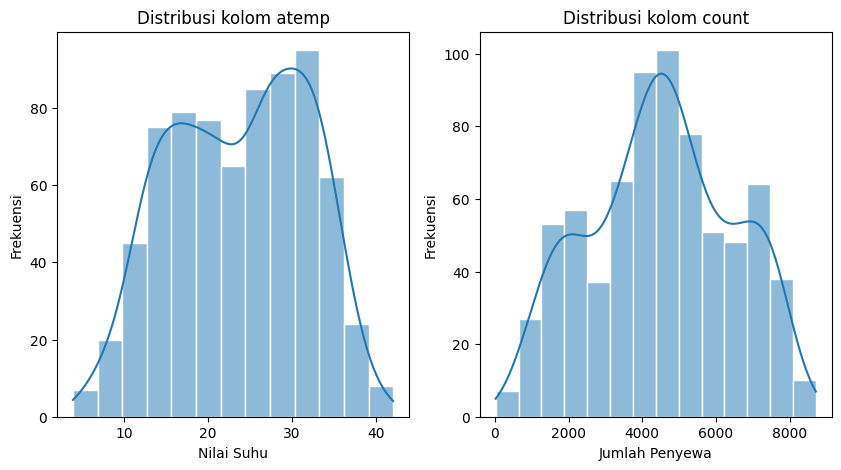

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(bike_day["atemp"], kde=True, edgecolor='white')
plt.title("Distribusi kolom atemp")
plt.ylabel("Frekuensi")
plt.xlabel("Nilai Suhu")

plt.subplot(1, 2, 2)
sns.histplot(bike_day["count"], kde=True, edgecolor='white')
plt.title("Distribusi kolom count")
plt.ylabel("Frekuensi")
plt.xlabel("Jumlah Penyewa")

plt.show()

**Melihat korelasi pada kolom `count` dan `atemp`**

In [ ]:
print("Nilai korelasi kolom count dan atemp :", bike_day["count"].corr(bike_day["atemp"]))

Nilai korelasi kolom count dan atemp : 0.6310656998491815


**Melihat jumlah penyewa sepeda berdasarkan tahun dan bulan**

In [ ]:
bike_day.groupby(by=["year", "month"], observed=False).agg({"count" : ["max", "min", "mean", "sum"]})

count                           
             max   min         mean     sum
year month                                 
2011 Apr    5312   795  3162.333333   94870
     Aug    5895  1115  4409.387097  136691
     Dec    3940   705  2816.870968   87323
     Feb    2927  1005  1721.964286   48215
     Jan    1985   431  1231.903226   38189
     Jul    6043  3285  4559.387097  141341
     Jun    5515  3767  4783.733333  143512
     Mar    3239   605  2065.967742   64045
     May    5805  2633  4381.322581  135821
     Nov    4486  1495  3405.566667  102167
     Oct    5511   627  3984.225806  123511
     Sep    5423  1842  4247.266667  127418
2012 Apr    7460  1027  5807.466667  174224
     Aug    7865  4549  6919.451613  214503
     Dec    6606   441  3990.741935  123713
     Feb    5062  1529  3556.448276  103137
     Jan    4521  1301  3120.774194   96744
     Jul    8173  4459  6567.967742  203607
     Jun    8120  4127  6761.000000  202830
     Mar    8362  3194  5318.548387  164875
     May    8294  2843  6318.225806  195865
     Nov    6852  2277  5088.800000  152664
     Oct    8156    22  6414.225806  198841
     Sep    8714  4073  7285.766667  218573

**Melihat pembagian bulan berdasarkan musim**

In [ ]:
bike_day.groupby(by=["season", "month"], observed=False)["date"].count()

season  month
fall    Aug      62
        Jul      62
        Jun      20
        Sep      44
spring  Dec      22
        Feb      57
        Jan      62
        Mar      40
summer  Apr      60
        Jun      40
        Mar      22
        May      62
winter  Dec      40
        Nov      60
        Oct      62
        Sep      16
Name: date, dtype: int64

**Melihat perbandingan banyak penyewa sepeda berdasarkan musim**

In [ ]:
bike_day.groupby(by="season", observed=False).agg({"count" : ["max", "min", "mean", "sum"]})

count                            
         max   min         mean      sum
season                                  
fall    8714  1115  5644.303191  1061129
spring  7836   431  2604.132597   471348
summer  8362   795  4992.331522   918589
winter  8555    22  4728.162921   841613

**Melihat perbandingan banyak penyewa sepeda berdasarkan cuaca**

In [ ]:
bike_day.groupby(by="weather", observed=False).agg({"count" : ["max", "min", "mean", "sum"]})

count                           
                      max  min         mean      sum
weather                                             
Clear/Partly Cloudy  8714  431  4876.786177  2257952
Light Rain/Snow      4639   22  1803.285714    37869
Misty/Cloudy         8362  605  4035.862348   996858

**Melakukan Binning**

Melakukan binning pada data `atemp` untuk memudahkan dalam menilai pengaruh suhu terhadap banyaknya penyewa sepeda.

Dilakukan dengan membagi data `atemp` kedalam 5 rentang tingkat suhu, untuk medapatkan 5 kategori :
- Very Cold
- Cold
- Moderate
- Hot
- Very Hot

In [ ]:
bin_edges = np.linspace(bike_day["atemp"].min(), bike_day["atemp"].max(), num=6)

bin_labels = ["Very Cold", "Cold", "Moderate", "Hot", "Very Hot"]

bike_day["atemp_range"] = pd.cut(bike_day["atemp"], bins=bin_edges, include_lowest=True)
bike_day["atemp_category"] = pd.cut(bike_day["atemp"], bins=bin_edges, labels=bin_labels, include_lowest=True)

bike_day.head()

,date,season,year,month,weather,atemp,count,atemp_range,atemp_category
0,2011-01-01,spring,2011,Jan,Misty/Cloudy,18.18125,985,"(11.572, 19.19]",Cold
1,2011-01-02,spring,2011,Jan,Misty/Cloudy,17.68695,801,"(11.572, 19.19]",Cold
2,2011-01-03,spring,2011,Jan,Clear/Partly Cloudy,9.47025,1349,"(3.952, 11.572]",Very Cold
3,2011-01-04,spring,2011,Jan,Clear/Partly Cloudy,10.60610,1562,"(3.952, 11.572]",Very Cold
4,2011-01-05,spring,2011,Jan,Clear/Partly Cloudy,11.46350,1600,"(3.952, 11.572]",Very Cold


In [ ]:
bike_day["atemp_range"].value_counts()

,count
atemp_range,
"(26.808, 34.427]",234
"(11.572, 19.19]",196
"(19.19, 26.808]",191
"(34.427, 42.045]",65
"(3.952, 11.572]",45


**Melihat perbandingan banyak penyewa sepeda berdasarkan tingkat suhu**

In [ ]:
bike_day.groupby(by="atemp_category", observed=False).agg({"atemp" : ["mean"],
                                                           "count" : ["max", "min", "mean", "sum"]})

atemp count                            
                     mean   max   min         mean      sum
atemp_category                                             
Very Cold        9.001955  3422   431  1606.355556    72286
Cold            15.355126  7148   605  3190.091837   625258
Moderate        23.046633  8555    22  4684.586387   894756
Hot             30.561621  8714  1115  5766.897436  1349454
Very Hot        36.455685  7592  3285  5398.846154   350925

**Melihat rata-rata suhu setiap musim**

In [ ]:
bike_day.groupby(by="season", observed=False).agg({"atemp" : ["max", "min", "mean", "sum"],
                                                   "count" : ["max", "min", "mean", "sum"]})

atemp                                   count                     \
             max       min       mean          sum   max   min         mean   
season                                                                        
fall    42.04480  12.12000  32.794920  6165.444900  8714  1115  5644.303191   
spring  27.43085   3.95348  14.845697  2687.071185  7836   431  2604.132597   
summer  37.87895  12.51695  26.015366  4786.827400  8362   795  4992.331522   
winter  30.39875  11.39565  20.776937  3698.294800  8555    22  4728.162921   

                 
            sum  
season           
fall    1061129  
spring   471348  
summer   918589  
winter   841613

**Insight:**
- Tidak terdapat keanehan pada nilai parameter.
- Distribusi data pada kolom `count` hampir seimbang, nilai mean dan mediannya memiliki sedikit perbedaan.
- Distribusi data pada kolom `atemp` memiliki dua puncak histogram, yaitu pada suhu 15 C yang merepresentasikan suhu dingin dan suhu 30 C dengan puncak tertinggi dan merepresentasikan suhu panas.
- Nilai korelasi untuk kolom `count` dan `atemp` sebesar 0.63, menandakan adanya korelasi positif antar kedua kolom.
- Binning dilakukan pada kolom `atempt` untuk memudahkan dalam melihat pengaruh suhu terasa terhadap banyaknya penyewa sepeda.

    Dari hasil binning didapatkan 5 tingkat suhu dengan rentang suhu :
    - Very Cold : 3.952 - 11.572
    - Cold : 11.572 - 19.19   
    - Moderate : 19.19 - 26.808
    - Hot : 26.808 - 34.427
    - Very Hot : 34.427 - 42.045


## **Visualization & Explanatory Analysis**

### **Pertanyaan 1: Bagaimana pola penyewaan sepeda pada tahun 2011 dan 2012?**

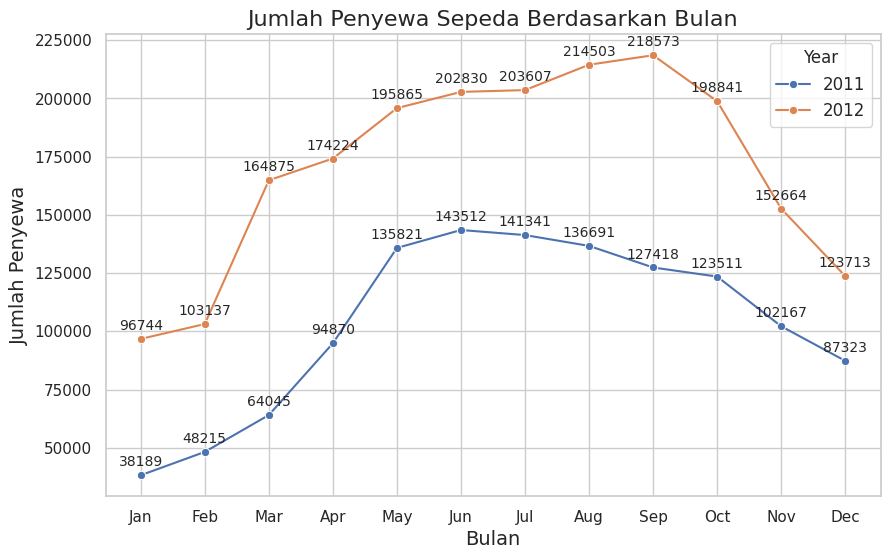

In [ ]:
# Mengelompokkan jumlah penyewa sepeda berdasarkan tahun dan bulan
monthly_rentals = bike_day.groupby(by=["year", "month"], observed=False)["count"].sum().reset_index()

# Mengurutkan data berdasarkan urutan bulan
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_rentals['month'] = pd.Categorical(monthly_rentals['month'], categories=month_order, ordered=True)
monthly_rentals = monthly_rentals.sort_values(by=["year", "month"])

# Membuat grafik line chart
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
ax = sns.lineplot(data=monthly_rentals, x='month', y='count', hue='year', errorbar=None, marker='o')

# Menambah keterangan grafik
ax.set_title('Jumlah Penyewa Sepeda Berdasarkan Bulan', fontsize=16)
ax.set_xlabel('Bulan', fontsize=14)
ax.set_ylabel('Jumlah Penyewa', fontsize=14)
ax.legend(title='Year', fontsize=12)

# Memberi anotasi nilai untuk setiap bulan
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.annotate(f"{int(y)}", xy=(x, y), xycoords='data',xytext=(0, 6),
                    textcoords='offset pixels', ha='center', va='bottom', fontsize=10)

plt.show()

In [ ]:
print(monthly_rentals.groupby(by="year")["count"].sum())

year
2011    1243103
2012    2049576
Name: count, dtype: int64


- Terjadi peningkatan jumlah penyewaan sepeda dari tahun 2011 ke 2012. Pada tahun 2011 terdapat 1.243.103 penyewa dan tahun 2012 terdapat 2.049.576 penyewa.

- Berdasarkan data selama dua tahun, jumlah penyewa sepeda meningkat pesat dari bulan Januari sampai Mei kemudian mengalami penurunan drastis pada bulan Oktober ke Desember. Dapat disimpulkan bahwa jumlah penyewaan sepeda meningkat dari awal tahun dan mencapai puncaknya di pertengahan tahun kemudian mengelami penurunan pada akhir tahun.

- Pada tahun 2011 penyewaan sepeda terbanyak terjadi pada bulan Juni sedangkan pada tahun 2012 penyewaan sepeda terbanyak terjadi pada bulan September. Penyewaan sepeda paling sedikit pada tahun 2011 dan 2012 sama-sama terjadi pada bulan Januari.

### **Pertanyaan 2: Dapatkah data penyewaan sepeda menunjukkan pembagian bulan permusim?**

In [ ]:
# Mengelompokan bulan berdasarkan musim
monthly_season = bike_day.groupby(by=["season", "month"], observed=False)["date"].count().reset_index()

# Membuat grafik sunburst
fig = px.sunburst(monthly_season, path=['season', 'month'], values='date')

# Menambahkan keterangan grafik
fig.update_layout(title='Pembagian Bulan Berdasarkan Musim', title_font_size=20,
                  title_font_weight='bold', title_x=0.5)

fig.show()

Berdasarkan grafik sunburst dapat dilihat bahwa :
- Musim spring berlangsung selama akhir Desember, Januari, Februari, sampai pertengahan bulan Maret
- Musim summer berlangsung selama akhir bulan Maret, April, Mei, sampai pertengahan bulan Juni
- Musim fall berlangsung selama akhir bulan Juni, Juli, Agustus, sampai pertengahan bulan September
- Musim winter berlangsung selama akhir bulan September, Oktober, November, sampai pertengahan bulan Desember

### **Pertanyaan 3: Bagaimana pengaruh musim terhadap banyaknya penyewa sepeda?**

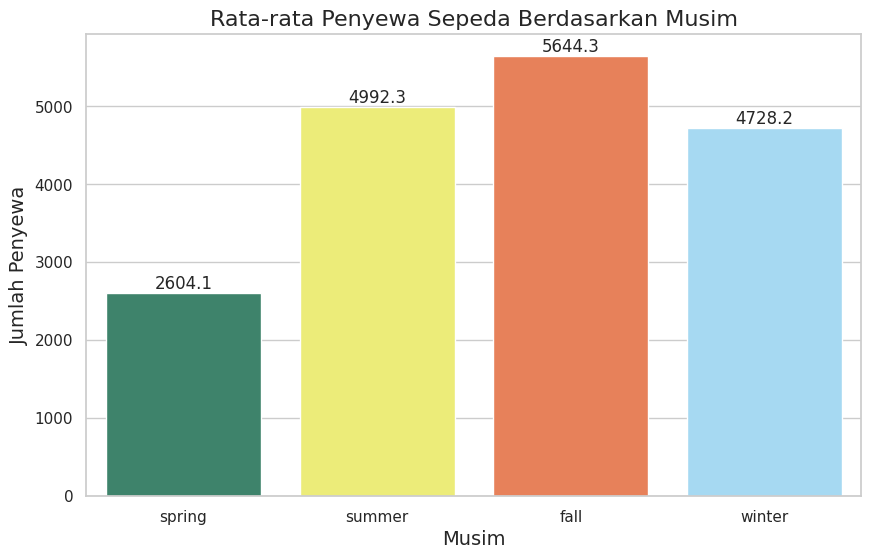

In [ ]:
# Membuat grafik bar chart
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=bike_day, x='season', y='count', hue='season',
                 palette=['#328E6E','#ffff66','#FE7743','#99ddff'], errorbar=None)

# Menambah keterangan grafik
ax.set_title('Rata-rata Penyewa Sepeda Berdasarkan Musim', fontsize=16)
ax.set_xlabel('Musim', fontsize=14)
ax.set_ylabel('Jumlah Penyewa', fontsize=14)

# Memberi anotasi nilai untuk setiap musim
for bar in ax.containers:
    ax.bar_label(bar, fmt= '%0.1f', label_type='edge' )

plt.show()

Berdasarkan grafik dapat dilihat bahwa musim dapat mempengaruhi banyaknya penyewaan sepeda. Berdasarkan rata-rata tertinggi, musim *fall* memiliki penyewaan sepeda paling banyak. Diikuti dengan musim *summer*, kemudian musim *winter*, dan musim dengan paling sedikit penyewa adalah musim *spring*.

### **Pertanyaan 4: Bagaimana pengaruh cuaca terhadap penyewaan sepeda?**

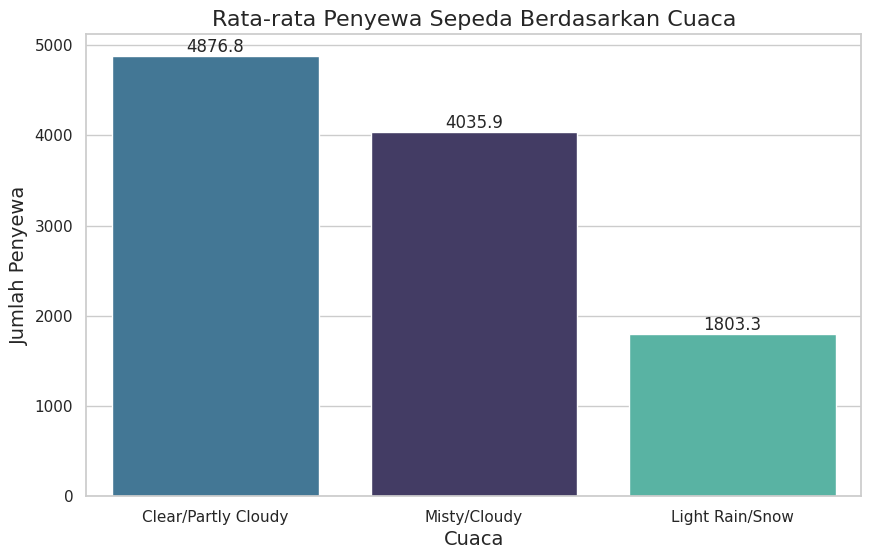

In [ ]:
# Membuat grafik bar chart
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=bike_day, x='weather', y='count', hue='weather',
                 palette='mako', order=bike_day.sort_values('count',ascending = False).weather, errorbar=None)

# Menambah keterangan grafik
ax.set_title('Rata-rata Penyewa Sepeda Berdasarkan Cuaca', fontsize=16)
ax.set_xlabel('Cuaca', fontsize=14)
ax.set_ylabel('Jumlah Penyewa', fontsize=14)

# Memberi anotasi nilai untuk setiap cuaca
for bar in ax.containers:
    ax.bar_label(bar, fmt= '%0.1f', label_type='edge' )

plt.show()

Dapat dilihat berdasarkan grafik, keadaan cuaca dapat mempengaruhi banyaknya penyewa sepeda. Penyewaan sepeda paling banyak terjadi saat cuaca dalam keadaan *clear* atau cerah, kemudian diikuti dengan cuaca *misty* atau berkabut, sedangkan penyewa sepeda paling sedikit terjadi saat cuaca *light rain* atau hujan

### **Pertanyaan 5: Bagaimana pengaruh tingkat suhu terhadap penyewaan sepeda?**

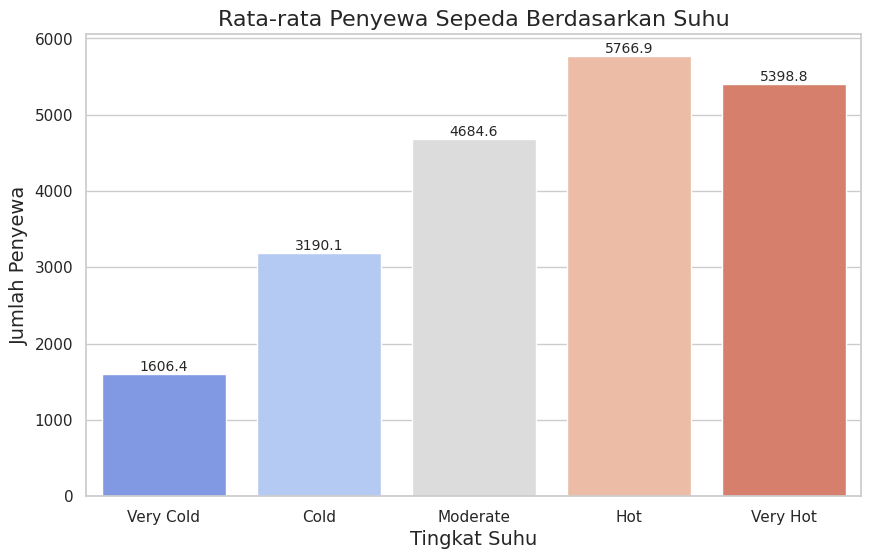

In [ ]:
# Membuat grafik bar chart
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=bike_day, x='atemp_category', y='count', hue='atemp_category',
                 palette='coolwarm', errorbar=None)

# Menambah keterangan grafik
ax.set_title('Rata-rata Penyewa Sepeda Berdasarkan Suhu', fontsize=16)
ax.set_xlabel('Tingkat Suhu', fontsize=14)
ax.set_ylabel('Jumlah Penyewa', fontsize=14)

# Memberi anotasi nilai untuk setiap tingkat suhu
for bar in ax.containers:
    ax.bar_label(bar, fmt= '%0.1f', label_type='edge', fontsize=10)

plt.show()

Berdasarkan data sebelumnya diketahui rentang suhu:
- Very Cold : 3.9 - 11.5
- Cold : 11.5 - 19.1   
- Moderate : 19.1 - 26.8
- Hot : 26.8 - 34.4
- Very Hot : 34.4 - 42.0

Menurut grafik, terjadi peningkatan jumlah penyewa dari tingkat suhu *very cold, cold, moderate*, dan kemudian memuncak pada tingkat *hot*, setelah itu kembali turun pada tingkat *very hot*. Dapat disimpulkan bahwa suhu dapat mempengaruhi jumlah penyewa sepeda. Suhu favorit penyewa sepeda ada pada tingkat *hot*, yaitu suhu dengan rentang 26.8 - 34.4 Celcius. Semakin suhu mendekati tingkat *hot*, semakin banyak juga jumlah penyewa sepeda.

### **Pertanyaan 6: Bagaimana hubungan musim dan suhu terhadap penyewaan sepeda?**

**Melihat hubungan suhu dan musim terhadap jumlah penyewa sepeda**

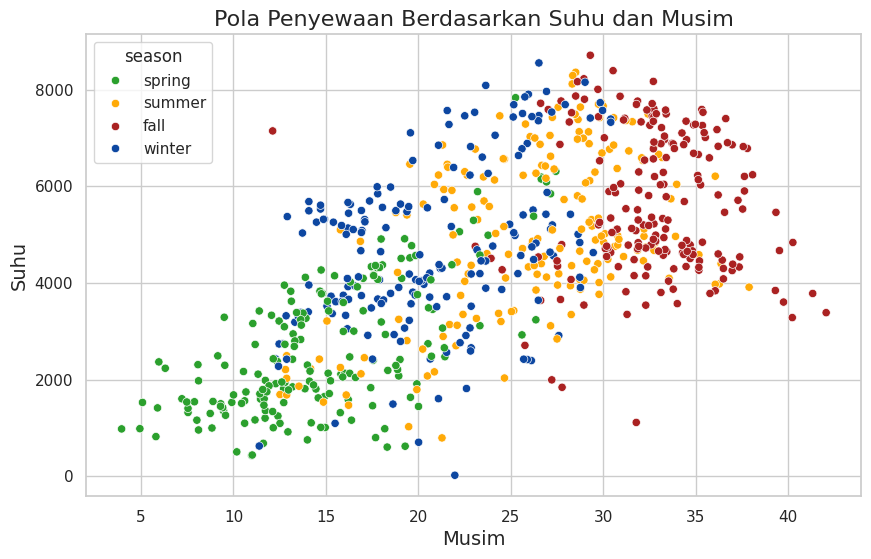

In [ ]:
# Membuat grafik scatterplot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.scatterplot(data=bike_day, x='atemp', y='count', hue='season',
                     palette=dict(spring='#2BA02D', summer='#ffaa08', fall='#AA2222', winter='#0D47A1'))

# Menambah keterangan grafik
ax.set_title('Pola Penyewaan Berdasarkan Suhu dan Musim', fontsize=16)
ax.set_xlabel('Musim', fontsize=14)
ax.set_ylabel('Suhu', fontsize=14)

plt.show()

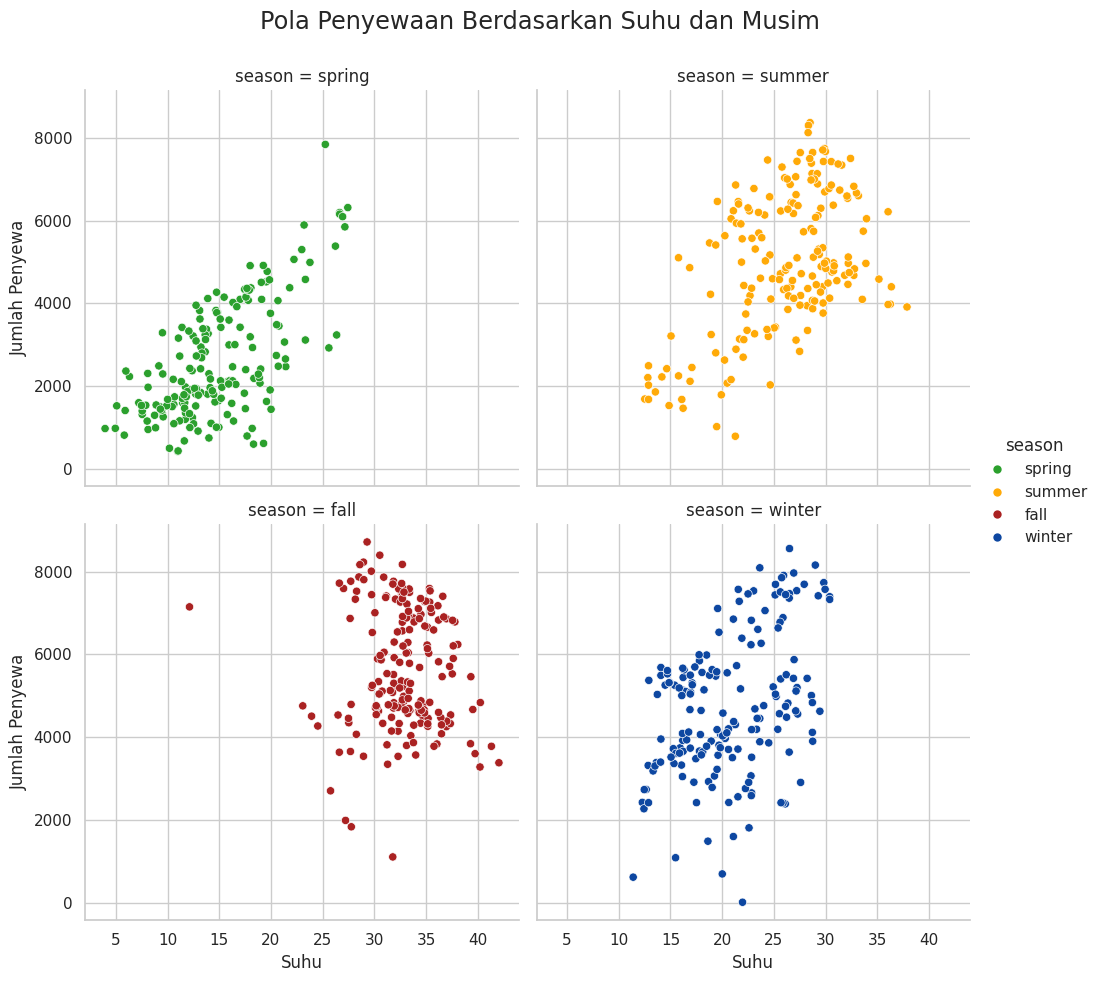

In [ ]:
# Membuat grafik scatterplot
sns.set_theme(style="whitegrid")
ax = sns.relplot(data=bike_day, x='atemp', y='count',hue='season', col='season', col_wrap=2,
                 palette=dict(spring='#2BA02D', summer='#ffaa08', fall='#AA2222', winter='#0D47A1'))

# Menambah keterangan grafik
ax.fig.suptitle("Pola Penyewaan Berdasarkan Suhu dan Musim",
               fontsize='x-large')

ax.fig.subplots_adjust(top=0.9)
ax.set_axis_labels('Suhu', 'Jumlah Penyewa' )

plt.show()

Berdasarkan grafik scatterplot diatas dapat disimpulkan bahwa musim dan cuaca memiliki pengaruh terhadap jumlah penyewa sepeda. Pada musim *spring*, *summer* dan *winter* terlihat jelas terjadi peningkatan jumlah penyewa ketika suhu meningkat, sedangkan pada musim *fall* distribusi data terlihat stabil di titik 6000 penyewa.

**Perbandingan suhu rata-rata setiap musim**

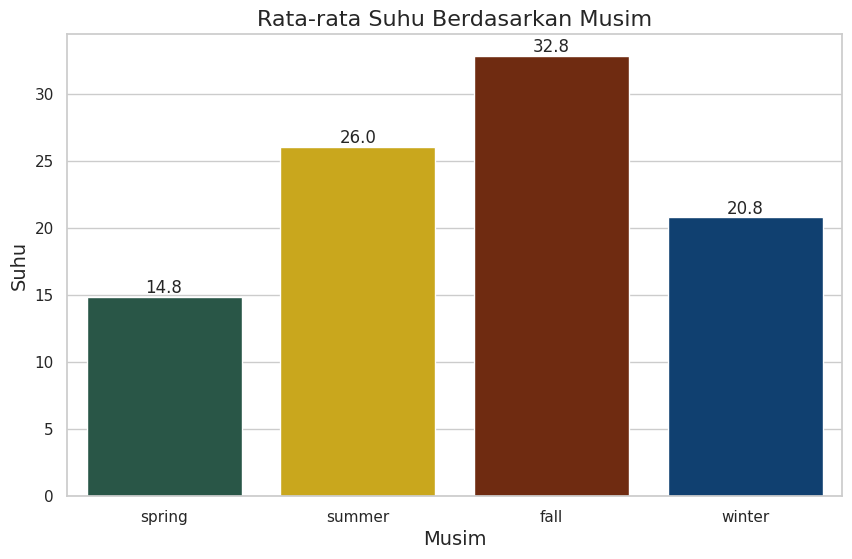

In [ ]:
# Membuat grafik bar chart
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=bike_day, x='season', y='atemp', hue='season',
                 palette=['#215e49', '#e6b800', '#7f2401', '#004080'], errorbar=None)

# Menambah keterangan grafik
ax.set_title('Rata-rata Suhu Berdasarkan Musim', fontsize=16)
ax.set_xlabel('Musim', fontsize=14)
ax.set_ylabel('Suhu', fontsize=14)

# Memberi anotasi suhu untuk setiap musim
for bar in ax.containers:
    ax.bar_label(bar, fmt= '%0.1f', label_type='edge' )

plt.show()

Berdasarkan grafik dapat kita lihat rata-rata suhu pada musim :
- spring : 14.8 C
- summer : 26 C
- fall : 32.8 C
- winter : 20.8 C

Dapat kita simpulkan musim *fall* memiliki rata-rata suhu tertinggi yaitu sebesar 32.8 C, suhu ini juga  termasuk dalam tingkat suhu *hot* favorit penyewa sepeda. Musim *summer* dan *winter* dengan rata-rata suhu 26 C dan 20.8 C termasuk dalam tingkat suhu *moderate*, dan *spring* memiliki rata-rata suhu terendah sebesar 14.8 C termasuk dalam kategori *cold*

## **Conclusion**

- **Conclution pertanyaan 1 :**
    
    Terjadi peningkatan jumlah penyewa sepeda dari tahun 2011 ke 2012.  Berdasarkan data selama dua tahun, jumlah penyewa sepeda meningkat pesat dari bulan Januari sampai bulan Mei lalu terus mengalami kenaikan hingga puncaknya. Kemudian mengalami penurunan drastis pada bulan Oktober ke Desember. Dapat disimpulkan bahwa jumlah penyewaan sepeda meningkat dari awal tahun dan mencapai puncaknya di pertengahan tahun kemudian mengelami penurunan pada akhir tahun.

- **Conclution pertanyaan 2 :**

    Berdasarkan grafik dapat dilihat bahwa :
    - Musim *spring* berlangsung selama akhir Desember, Januari, Februari, sampai pertengahan bulan Maret.
    - Musim *summer* berlangsung selama akhir bulan Maret, April, Mei, sampai pertengahan bulan Juni.
    - Musim *fall* berlangsung selama akhir bulan Juni, Juli, Agustus, sampai pertengahan bulan September.
    - Musim *winter* berlangsung selama akhir bulan September, Oktober, November, sampai pertengahan bulan Desember.

- **Conclution pertanyaan 3 :**

    Dapat disimpulkan bahwa musim dapat mempengaruhi banyaknya penyewa sepeda. Musim *fall* memiliki rata-rata penyewaan sepeda terbanyak. Diikuti dengan musim *summer*, kemudian musim *winter*, dan musim *spring* dengan paling sedikit penyewa.

- **Conclution pertanyaan 4 :**

    Dapat disimpulkan bahwa keadaan cuaca dapat mempengaruhi banyaknya penyewa sepeda. Penyewaan sepeda paling banyak terjadi saat cuaca dalam keadaan *clear* atau cerah, kemudian diikuti dengan cuaca *misty* atau berkabut, sedangkan penyewa sepeda paling sedikit terjadi saat cuaca *light rain* atau hujan.

- **Conclution pertanyaan 5 :**

    Berdasarkan kategori tingkat suhu :
    - Very Cold : 3.9 - 11.5
    - Cold : 11.5 - 19.1   
    - Moderate : 19.1 - 26.8
    - Hot : 26.8 - 34.4
    - Very Hot : 34.4 - 42.0

  Dapat disimpulkan bahwa suhu dapat mempengaruhi jumlah penyewa sepeda. Suhu yang paling diminati penyewa sepeda ada pada tingkat *hot*, yaitu suhu dengan rentang 26.8 - 34.4 Celcius. Karena merupakan puncak suhu kesukaan penyewa spepeda, semakin suhu mendekati tingkat *hot*, semakin banyak juga jumlah penyewa sepeda. Sebaliknya, jika suhu menjauhi atau melewati tingkat hot maka jumlah penyewa sepeda akan menurun.

- **Conclution pertanyaan 6 :**

    Berdasarkan grafik dapat kita lihat rata-rata suhu pada musim :
    - spring : 14.8 C
    - summer : 26 C
    - fall : 32.8 C
    - winter : 20.8 C

  Dapat kita simpulkan musim *fall* memiliki rata-rata suhu tertinggi yaitu sebesar 32.8 C, suhu ini juga  termasuk dalam tingkat suhu *hot* yang paling diminati penyewa sepeda. Musim *summer* dan *winter* dengan rata-rata suhu 26 C dan 20.8 C termasuk dalam tingkat suhu *moderate*, dan *spring* memiliki rata-rata suhu terendah sebesar 14.8 C termasuk dalam kategori *cold*.
    
  Jika dibandingkan dengan grafik rata-rata penyewa berdasarkan musim akan terlihat kesamaan, dengan musim *fall* memiliki urutan pertama pada rata-rata penyewa sepeda tertinggi dan rata-rata suhu tertinggi. Diikuti dengan musim *summer* dan musim *winter*, kemudian musim *spring* yang memiliki rata-rata penyewa sepeda terendah dan rata-rata suhu terendah.

**Menyimpan hasil akhir data `bike_day`**

In [ ]:
bike_day.to_csv("final_day.csv", index=False)